In [1]:
import pandas as pd
from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import OLSInfluence
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import Lasso, LassoCV
from statsmodels.stats.anova import anova_lm

In [2]:
# Load dataset
df = pd.read_csv("Dataset/academic_meals_elementary_district.csv")

print("Original shape:", df.shape)

Original shape: (54, 263)


In [3]:
total_nulls = df.isnull().sum().sum()

print("Total missing values in dataset:", total_nulls)

Total missing values in dataset: 1


In [4]:
null_per_column = df.isnull().sum()

print(null_per_column)

District                         0
ROE                              0
student_disabilities_percent     1
student_low_income_percent       0
days_entered.x                   0
                                ..
Science_Proficiency              0
Science_Proficiency_LowIncome    0
Science_Proficiency_CWD          0
missing_frac                     0
missing_count                    0
Length: 263, dtype: int64


In [5]:
# Check which row has missing value
df[df["student_disabilities_percent"].isnull()]

,District,ROE,student_disabilities_percent,student_low_income_percent,days_entered.x,HEI 2015 Total Score,HEI 2015 Total Fruits (0-5),HEI 2015 Whole Fruits (0-5),HEI 2015 Total Vegetables (0-5),HEI 2015 Greens and Beans (0-5),...,ELA_Proficiency_LowIncome,ELA_Proficiency_CWD,Math_Proficiency,Math_Proficiency_LowIncome,Math_Proficiency_CWD,Science_Proficiency,Science_Proficiency_LowIncome,Science_Proficiency_CWD,missing_frac,missing_count
27,LOSTANT CUSD 425,35.0,NaN,26.8,21.0,67.000048,5.0,5.0,2.93481,3.043476,...,60.558345,44.231892,30.8,27.499899,27.739182,42.316915,40.73494,51.344596,0.7,7.0


In [6]:
median_value = df["student_disabilities_percent"].median()

df["student_disabilities_percent"] = df["student_disabilities_percent"].fillna(median_value)

print("Missing after imputation:", df["student_disabilities_percent"].isnull().sum())

Missing after imputation: 0


In [7]:
cols_to_drop = [
    # Identifiers
    "ROE",
    
    # Tracking / merge artifacts
    "days_entered.x",
    "days_entered.y",
    "Day of Menu",
    
    # Metadata
    "Data Collected in NCC Database Version",
    "Data Collected in Software Version",
    "Data Generated in NCC Database Version",
    "Data Generated in Software Version",
    
    # Missing diagnostics 
    "missing_frac",
    "missing_count",

    "ELA_Proficiency_LowIncome",
    "ELA_Proficiency_CWD",
    "Math_Proficiency_LowIncome",
    "Math_Proficiency_CWD",
    "Science_Proficiency_LowIncome",
    "Science_Proficiency_CWD"
]

In [8]:
df_clean = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

print("After removing non-analytical columns:", df_clean.shape)

After removing non-analytical columns: (54, 247)


In [9]:
removed = set(df.columns) - set(df_clean.columns)
print("Removed columns:")
print(removed)

Removed columns:
{'days_entered.y', 'days_entered.x', 'Science_Proficiency_CWD', 'Day of Menu', 'missing_count', 'Data Generated in NCC Database Version', 'Math_Proficiency_LowIncome', 'Science_Proficiency_LowIncome', 'Math_Proficiency_CWD', 'ELA_Proficiency_CWD', 'missing_frac', 'Data Generated in Software Version', 'Data Collected in NCC Database Version', 'ROE', 'ELA_Proficiency_LowIncome', 'Data Collected in Software Version'}


In [10]:
# Identify columns ending with .x or .y
x_cols = [col for col in df_clean.columns if col.endswith(".x")]
y_cols = [col for col in df_clean.columns if col.endswith(".y")]

print("Columns ending with .x:", x_cols)
print("Columns ending with .y:", y_cols)

Columns ending with .x: ['% Calories from SFA.x', 'Total Saturated Fatty Acids (SFA) (g).x', 'Energy (kcal).x']
Columns ending with .y: ['Energy (kcal).y', 'Total Saturated Fatty Acids (SFA) (g).y', '% Calories from SFA.y']


In [11]:
# Remove .x / .y Duplicate Columns 
cols_to_drop = []

for col in x_cols:
    base_name = col[:-2]  # remove ".x"
    y_version = base_name + ".y"
    
    if y_version in df_clean.columns:
        # If both exist, drop the .y version
        cols_to_drop.append(y_version)

df_clean = df_clean.drop(columns=cols_to_drop)

print("Removed duplicate .y columns")
print("New shape:", df_clean.shape)

Removed duplicate .y columns
New shape: (54, 244)


In [12]:
# Remove EXACT Duplicate Columns (Same Values)
import numpy as np

duplicate_columns = []

for i in range(len(df_clean.columns)):
    for j in range(i + 1, len(df_clean.columns)):
        col1 = df_clean.columns[i]
        col2 = df_clean.columns[j]
        
        if df_clean[col1].equals(df_clean[col2]):
            duplicate_columns.append(col2)

# Remove duplicates
df_clean = df_clean.drop(columns=list(set(duplicate_columns)))

print("Exact duplicate columns removed:", duplicate_columns)
print("Shape after removing exact duplicates:", df_clean.shape)

Exact duplicate columns removed: ['Whole Grains (ounce equivalents)', 'Refined Grains (ounce equivalents)', 'Sucrose Polyester (g)', 'User Nutrient 1 (mg)', 'User Nutrient 2 (mg)', 'User Nutrient 3 (mg)', 'User Nutrient 4 (mg)', 'User Nutrient 5 (mg)', 'User Nutrient 6 (mg)', 'User Nutrient 7 (mg)', 'User Nutrient 8 (mg)', 'User Nutrient 9 (mg)', 'User Nutrient 10 (mg)', 'User Nutrient 11 (mg)', 'User Nutrient 12 (mg)', 'User Nutrient 13 (mg)', 'User Nutrient 14 (mg)', 'User Nutrient 15 (mg)', 'User Nutrient 16 (mg)', 'User Nutrient 17 (mg)', 'User Nutrient 18 (mg)', 'User Nutrient 19 (mg)', 'User Nutrient 20 (mg)', 'Sucralose (mg)', 'Isomalt (g)', 'Lactitol (g)', 'User Nutrient 1 (mg)', 'User Nutrient 2 (mg)', 'User Nutrient 3 (mg)', 'User Nutrient 4 (mg)', 'User Nutrient 5 (mg)', 'User Nutrient 6 (mg)', 'User Nutrient 7 (mg)', 'User Nutrient 8 (mg)', 'User Nutrient 9 (mg)', 'User Nutrient 10 (mg)', 'User Nutrient 11 (mg)', 'User Nutrient 12 (mg)', 'User Nutrient 13 (mg)', 'User Nutri

In [13]:
# Remove Duplicate Energy Columns
energy_cols = [col for col in df_clean.columns if "Energy" in col]
print("Energy-related columns:", energy_cols)

Energy-related columns: ['Energy (kcal).x', 'Energy (kj)']


In [14]:
if "Energy (kj)" in df_clean.columns:
    df_clean = df_clean.drop(columns=["Energy (kj)"])

In [15]:
print("Final shape after duplicate removal:", df_clean.shape)

Final shape after duplicate removal: (54, 217)


In [16]:
# Keep numeric columns only
df_numeric = df_clean.select_dtypes(include=[np.number])

print("Numeric shape:", df_numeric.shape)

Numeric shape: (54, 216)


In [17]:
variances = df_numeric.var()

# Look at smallest variances
variances.sort_values().head(10)

Saccharin (mg)                                     0.000000e+00
Maltitol (g)                                       4.053150e-08
Erythritol (g)                                     3.200367e-07
PUFA 20:5 n-3 (eicosapentaenoic acid [EPA]) (g)    1.626067e-05
Xylitol (g)                                        4.483152e-05
CLA trans-10, cis-12 (g)                           4.506519e-05
PUFA 22:5 n-3 (docosapentaenoic acid [DPA]) (g)    4.847515e-05
% Calories from Alcohol                            7.560004e-05
PUFA 18:4 (parinaric acid) (g)                     7.758662e-05
PUFA 22:6 n-3 (docosahexaenoic acid [DHA]) (g)     8.634814e-05
dtype: float64

In [18]:
from sklearn.feature_selection import VarianceThreshold

# Set small threshold
selector = VarianceThreshold(threshold=0.01)

X_reduced = selector.fit_transform(df_numeric)

# Get kept columns
kept_columns = df_numeric.columns[selector.get_support()]

# Create new cleaned dataframe
df_variance_clean = df_numeric[kept_columns]

print("Before variance filtering:", df_numeric.shape)
print("After variance filtering:", df_variance_clean.shape)

Before variance filtering: (54, 216)
After variance filtering: (54, 191)


In [19]:
df_variance_clean.columns

Index(['student_disabilities_percent', 'student_low_income_percent',
       'HEI 2015 Total Score', 'HEI 2015 Total Fruits (0-5)',
       'HEI 2015 Whole Fruits (0-5)', 'HEI 2015 Total Vegetables (0-5)',
       'HEI 2015 Greens and Beans (0-5)', 'HEI 2015 Whole Grains (0-10)',
       'HEI 2015 Dairy (0-10)', 'HEI 2015 Total Protein Foods (0-5)',
       ...
       'Total Lignans (mcg)', 'Secoisolariciresinol (mcg)',
       'Matairesinol (mcg)', 'Lariciresinol (mcg)', 'Pinoresinol (mcg)',
       'PUFA 18:2 n-6 (linoleic acid [LA]) (g)', 'Omega-6 Fatty Acids (g)',
       'ELA_Proficiency', 'Math_Proficiency', 'Science_Proficiency'],
      dtype='object', length=191)

In [20]:
print(df_variance_clean.columns.tolist())

['student_disabilities_percent', 'student_low_income_percent', 'HEI 2015 Total Score', 'HEI 2015 Total Fruits (0-5)', 'HEI 2015 Whole Fruits (0-5)', 'HEI 2015 Total Vegetables (0-5)', 'HEI 2015 Greens and Beans (0-5)', 'HEI 2015 Whole Grains (0-10)', 'HEI 2015 Dairy (0-10)', 'HEI 2015 Total Protein Foods (0-5)', 'HEI 2015 Seafood and Plant Proteins (0-5)', 'HEI 2015 Fatty Acids (0-10)', 'HEI 2015 Refined Grains (0-10)', 'HEI 2015 Sodium (0-10)', 'HEI 2015 Added Sugars (0-10)', 'HEI 2015 Saturated Fats (0-10)', 'Total Fruit Servings in cup equivalents per 1000 kcal', 'Whole Fruit Servings in cup equivalents per 1000 kcal', 'Total Vegetable Servings in cup equivalents per 1000 kcal', 'Greens and Beans Servings in cup equivalents per 1000 kcal', 'Whole Grain Servings in ounce equivalents per 1000 kcal', 'Dairy Servings in cup equivalents per 1000 kcal', 'Total Protein Servings in ounce equivalents per 1000 kcal', 'Seafood and Plant Protein Servings in ounce equivalents per 1000 kcal', 'Fa

In [21]:
# Response variables
response_vars = [
    'ELA_Proficiency',
    'Math_Proficiency',
    'Science_Proficiency'
]

# SES variables
ses_vars = [
    'student_disabilities_percent',
    'student_low_income_percent'
]

# HEI total + HEI component score variables
hei_vars = [col for col in df_variance_clean.columns if col.startswith('HEI 2015')]

# Remaining nutrition variables
nutrition_vars = [
    col for col in df_variance_clean.columns
    if col not in response_vars + ses_vars + hei_vars
]

In [22]:
# Print counts
print("Number of response variables:", len(response_vars))
print("Number of SES variables:", len(ses_vars))
print("Number of HEI variables:", len(hei_vars))
print("Number of other nutrition variables:", len(nutrition_vars))

Number of response variables: 3
Number of SES variables: 2
Number of HEI variables: 14
Number of other nutrition variables: 172


In [23]:
print("\nResponse variables:")
print(response_vars)

print("\nSES variables:")
print(ses_vars)

print("\nHEI variables:")
print(hei_vars)

print("\nFirst 20 other nutrition variables:")
print(nutrition_vars[:20])


Response variables:
['ELA_Proficiency', 'Math_Proficiency', 'Science_Proficiency']

SES variables:
['student_disabilities_percent', 'student_low_income_percent']

HEI variables:
['HEI 2015 Total Score', 'HEI 2015 Total Fruits (0-5)', 'HEI 2015 Whole Fruits (0-5)', 'HEI 2015 Total Vegetables (0-5)', 'HEI 2015 Greens and Beans (0-5)', 'HEI 2015 Whole Grains (0-10)', 'HEI 2015 Dairy (0-10)', 'HEI 2015 Total Protein Foods (0-5)', 'HEI 2015 Seafood and Plant Proteins (0-5)', 'HEI 2015 Fatty Acids (0-10)', 'HEI 2015 Refined Grains (0-10)', 'HEI 2015 Sodium (0-10)', 'HEI 2015 Added Sugars (0-10)', 'HEI 2015 Saturated Fats (0-10)']

First 20 other nutrition variables:
['Total Fruit Servings in cup equivalents per 1000 kcal', 'Whole Fruit Servings in cup equivalents per 1000 kcal', 'Total Vegetable Servings in cup equivalents per 1000 kcal', 'Greens and Beans Servings in cup equivalents per 1000 kcal', 'Whole Grain Servings in ounce equivalents per 1000 kcal', 'Dairy Servings in cup equivalent

### MODEL 1: REMOVE MULTICOLLINEARIY & FIT OLS

In [24]:
# outcomes
outcomes = ['ELA_Proficiency', 'Math_Proficiency', 'Science_Proficiency']

# SES variables
ses_vars = [
    'student_low_income_percent',
    'student_disabilities_percent'
]

# nutrition candidate variables only
nutrition_vars = [
    col for col in df_variance_clean.columns
    if col not in outcomes + ses_vars
]

print("Number of nutrition variables:", len(nutrition_vars))

Number of nutrition variables: 186


In [25]:
nutrition_corr = df_variance_clean[nutrition_vars].corr().abs()
nutrition_corr.head()

,HEI 2015 Total Score,HEI 2015 Total Fruits (0-5),HEI 2015 Whole Fruits (0-5),HEI 2015 Total Vegetables (0-5),HEI 2015 Greens and Beans (0-5),HEI 2015 Whole Grains (0-10),HEI 2015 Dairy (0-10),HEI 2015 Total Protein Foods (0-5),HEI 2015 Seafood and Plant Proteins (0-5),HEI 2015 Fatty Acids (0-10),...,PUFA 18:3 n-3 (alpha-linolenic acid [ALA]) (g),Solid Fats (g),Gluten (g),Total Lignans (mcg),Secoisolariciresinol (mcg),Matairesinol (mcg),Lariciresinol (mcg),Pinoresinol (mcg),PUFA 18:2 n-6 (linoleic acid [LA]) (g),Omega-6 Fatty Acids (g)
HEI 2015 Total Score,1.000000,0.591346,0.670081,0.112862,0.371052,0.267387,0.734048,0.207044,0.423870,0.012596,...,0.002370,0.061689,0.029813,0.427748,0.251003,0.421996,0.526300,0.272211,0.130630,0.129237
HEI 2015 Total Fruits (0-5),0.591346,1.000000,0.886485,0.198958,0.066154,0.133492,0.380807,0.347066,0.186979,0.375366,...,0.199178,0.161632,0.341648,0.011515,0.143938,0.066014,0.023350,0.156213,0.194138,0.193922
HEI 2015 Whole Fruits (0-5),0.670081,0.886485,1.000000,0.256720,0.167618,0.155783,0.405953,0.271623,0.034627,0.175860,...,0.173251,0.170642,0.250714,0.031415,0.128312,0.043891,0.130364,0.110519,0.129237,0.129562
HEI 2015 Total Vegetables (0-5),0.112862,0.198958,0.256720,1.000000,0.624900,0.562289,0.001768,0.028265,0.117375,0.020168,...,0.204737,0.318338,0.427371,0.139576,0.039479,0.196885,0.003438,0.207494,0.248981,0.249081
HEI 2015 Greens and Beans (0-5),0.371052,0.066154,0.167618,0.624900,1.000000,0.191071,0.190860,0.089849,0.233706,0.055540,...,0.058095,0.074653,0.129551,0.430834,0.096459,0.098675,0.332343,0.500093,0.075255,0.074691


In [26]:
threshold = 0.85

upper_triangle = nutrition_corr.where(
    np.triu(np.ones(nutrition_corr.shape), k=1).astype(bool)
)

high_corr_pairs = []

In [27]:
for col in upper_triangle.columns:
    for row in upper_triangle.index:
        corr_value = upper_triangle.loc[row, col]
        if pd.notna(corr_value) and corr_value > threshold:
            high_corr_pairs.append((row, col, corr_value))

In [28]:
high_corr_df = pd.DataFrame(high_corr_pairs, columns=['var1', 'var2', 'abs_correlation'])
high_corr_df = high_corr_df.sort_values('abs_correlation', ascending=False)

high_corr_df.head(30)

,var1,var2,abs_correlation
2095,Aspartame (mg),Acesulfame Potassium (mg),1.000000
2441,Kcals from Added Sugars (by Total Sugars),Added Sugars (by Total Sugars) (g),1.000000
423,Sodium (g),Sodium (mg),1.000000
2283,Glycemic Load (glucose reference),Glycemic Load (bread reference),1.000000
2154,Glycemic Index (glucose reference),Glycemic Index (bread reference),0.999999
2660,PUFA 18:2 n-6 (linoleic acid [LA]) (g),Omega-6 Fatty Acids (g),0.999993
20,Total Saturated Fatty Acids (SFA) (g).x,Kcals from Saturated Fats,0.999961
2075,Daidzein (mg),Genistein (mg),0.999960
2360,Total Protein (g),Nitrogen (g),0.999882
2517,"PUFA 18:3 (linolenic acid, undifferentiated) (g)",PUFA 18:3 n-3 (alpha-linolenic acid [ALA]) (g),0.999870


In [29]:
to_drop = set()

for var1, var2, corr_val in high_corr_pairs:
    if var2 not in to_drop and var1 not in to_drop:
        to_drop.add(var2)

reduced_nutrition_vars = [col for col in nutrition_vars if col not in to_drop]

In [30]:
print("Original nutrition variables:", len(nutrition_vars))
print("Dropped due to high correlation:", len(to_drop))
print("Remaining nutrition variables:", len(reduced_nutrition_vars))

print("\nDropped variables:")
print(sorted(to_drop))

Original nutrition variables: 186
Dropped due to high correlation: 133
Remaining nutrition variables: 53

Dropped variables:
['% Calories from Added Sugars (by Total Sugars)', '% Calories from Carbohydrate', '% Calories from MUFA', '% Calories from SFA.x', 'Acesulfame Potassium (mg)', 'Added Sugars (by Available Carbohydrate) (g)', 'Added Sugars (by Total Sugars) (g)', 'Alanine (g)', 'Alpha-Carotene (provitamin A carotenoid) (mcg)', 'Arginine (g)', 'Ash (g)', 'Aspartic Acid (g)', 'Available Carbohydrate (g)', 'Beta-Carotene (provitamin A carotenoid) (mcg)', 'Beta-Carotene Equivalents (derived from provitamin A carotenoids) (mcg)', 'Betaine (mg)', 'Caffeine (mg)', 'Calcium (mg)', 'Cholesterol (mg)', 'Cholesterol to Saturated Fatty Acid Index', 'Choline (mg)', 'Copper (mg)', 'Cystine (g)', 'Dairy Servings in cup equivalents per 1000 kcal', 'Dietary Folate Equivalents (mcg)', 'Energy (kcal).x', 'Fatty Acids Ratio', 'Fructose (g)', 'Gamma-Tocopherol (mg)', 'Genistein (mg)', 'Glucose (g)', 

In [31]:
X_vif = df_variance_clean[reduced_nutrition_vars].copy()

vif_df = pd.DataFrame({
    'Predictor': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})

In [32]:
vif_df = vif_df.sort_values('VIF', ascending=False)
vif_df

,Predictor,VIF
23,Total Polyunsaturated Fatty Acids (PUFA) (g) a...,173612.174169
0,HEI 2015 Total Score,141580.314984
11,HEI 2015 Added Sugars (0-10),103723.377691
25,Animal Protein (g),80330.122864
36,% Calories from Fat,53023.574766
45,Glycemic Index (glucose reference),42363.127858
22,Total Protein Servings in ounce equivalents,41516.810187
37,% Calories from Protein,37057.290576
24,Kcals from Added Sugars (by Total Sugars),32705.170434
15,Total Protein Servings in ounce equivalents pe...,19773.690132


In [33]:
def compute_vif(df, predictors):
    X = df[predictors].copy()
    vif_df = pd.DataFrame({
        'Predictor': X.columns,
        'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    })
    return vif_df.sort_values('VIF', ascending=False)

In [34]:
vif_reduced_nutrition = compute_vif(df_variance_clean, reduced_nutrition_vars)
vif_reduced_nutrition.head(20)

,Predictor,VIF
23,Total Polyunsaturated Fatty Acids (PUFA) (g) a...,173612.174169
0,HEI 2015 Total Score,141580.314984
11,HEI 2015 Added Sugars (0-10),103723.377691
25,Animal Protein (g),80330.122864
36,% Calories from Fat,53023.574766
45,Glycemic Index (glucose reference),42363.127858
22,Total Protein Servings in ounce equivalents,41516.810187
37,% Calories from Protein,37057.290576
24,Kcals from Added Sugars (by Total Sugars),32705.170434
15,Total Protein Servings in ounce equivalents pe...,19773.690132


In [35]:
def reduce_vif(df, predictors, vif_threshold=10):
    remaining_vars = predictors.copy()
    removed_vars = []
    
    while True:
        vif_df = compute_vif(df, remaining_vars)
        max_vif = vif_df['VIF'].max()
        
        if max_vif <= vif_threshold:
            break
        
        worst_var = vif_df.iloc[0]['Predictor']
        worst_vif = vif_df.iloc[0]['VIF']
        
        remaining_vars.remove(worst_var)
        removed_vars.append((worst_var, worst_vif))
        
        print(f"Removed {worst_var} with VIF = {worst_vif:.2f}")
    
    final_vif = compute_vif(df, remaining_vars)
    return remaining_vars, removed_vars, final_vif

In [36]:
vif_clean_nutrition_vars, removed_vif_vars, final_vif_table = reduce_vif(
    df_variance_clean,
    reduced_nutrition_vars,
    vif_threshold=10
)

Removed Total Polyunsaturated Fatty Acids (PUFA) (g) and Total Monounsaturated Fatty Acids (MUFA) (g) with VIF = 173612.17
Removed HEI 2015 Total Score with VIF = 141578.80
Removed Animal Protein (g) with VIF = 33934.99
Removed % Calories from Protein with VIF = 10208.36
Removed % Calories from Fat with VIF = 8852.40
Removed Total Dietary Fiber (g) with VIF = 3162.02
Removed Glycemic Index (glucose reference) with VIF = 2572.67
Removed Vitamin K (phylloquinone) (mcg) with VIF = 1696.71
Removed Total Protein Servings in ounce equivalents with VIF = 1644.57
Removed HEI 2015 Added Sugars (0-10) with VIF = 1167.98
Removed HEI 2015 Total Protein Foods (0-5) with VIF = 886.87
Removed HEI 2015 Total Fruits (0-5) with VIF = 466.33
Removed HEI 2015 Saturated Fats (0-10) with VIF = 408.06
Removed % Calories from PUFA with VIF = 394.99
Removed HEI 2015 Total Vegetables (0-5) with VIF = 301.64
Removed Delta-Tocopherol (mg) with VIF = 261.11
Removed Whole Fruit Servings in cup equivalents with VIF 

In [37]:
print("\nOriginal reduced_nutrition_vars:", len(reduced_nutrition_vars))
print("Removed by VIF filtering:", len(removed_vif_vars))
print("Final VIF-cleaned nutrition vars:", len(vif_clean_nutrition_vars))


Original reduced_nutrition_vars: 53
Removed by VIF filtering: 37
Final VIF-cleaned nutrition vars: 16


In [38]:
removed_vif_df = pd.DataFrame(removed_vif_vars, columns=['Removed_Variable', 'VIF_at_Removal'])

In [39]:
final_vif_table

,Predictor,VIF
8,TRANS 18:1 (trans-octadecenoic acid) (g),7.782450
7,3-Methylhistidine (mg),7.756311
12,Mannitol (g),7.685965
13,Sorbitol (g),7.418933
0,HEI 2015 Greens and Beans (0-5),6.845989
5,Beta-Tocopherol (mg),6.766840
3,Seafood and Plant Protein Servings in ounce eq...,6.029183
2,Whole Fruit Servings in cup equivalents per 10...,5.224193
1,HEI 2015 Whole Grains (0-10),4.459261
4,Galactose (g),2.905277


In [40]:
print(vif_clean_nutrition_vars)

['HEI 2015 Greens and Beans (0-5)', 'HEI 2015 Whole Grains (0-10)', 'Whole Fruit Servings in cup equivalents per 1000 kcal', 'Seafood and Plant Protein Servings in ounce equivalents per 1000 kcal', 'Galactose (g)', 'Beta-Tocopherol (mg)', 'Aspartame (mg)', '3-Methylhistidine (mg)', 'TRANS 18:1 (trans-octadecenoic acid) (g)', 'Synthetic Alpha-Tocopherol (all rac-alpha-tocopherol or dl-alpha-tocopherol) (mg)', 'Daidzein (mg)', 'Biochanin A (mg)', 'Mannitol (g)', 'Sorbitol (g)', 'Tagatose (mg)', 'Secoisolariciresinol (mcg)']


### Fitting the model

In [41]:
ses_vars = [
    'student_low_income_percent',
    'student_disabilities_percent'
]

target_outcome = 'ELA_Proficiency'  

final_predictors = ses_vars + vif_clean_nutrition_vars

X = df_variance_clean[final_predictors].copy()
y = df_variance_clean[target_outcome].copy()

X = sm.add_constant(X)
vif_clean_model = sm.OLS(y, X).fit()

print(vif_clean_model.summary())

                            OLS Regression Results                            
Dep. Variable:        ELA_Proficiency   R-squared:                       0.824
Model:                            OLS   Adj. R-squared:                  0.734
Method:                 Least Squares   F-statistic:                     9.123
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           1.85e-08
Time:                        20:48:06   Log-Likelihood:                -190.61
No. Observations:                  54   AIC:                             419.2
Df Residuals:                      35   BIC:                             457.0
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                                                                                        coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------

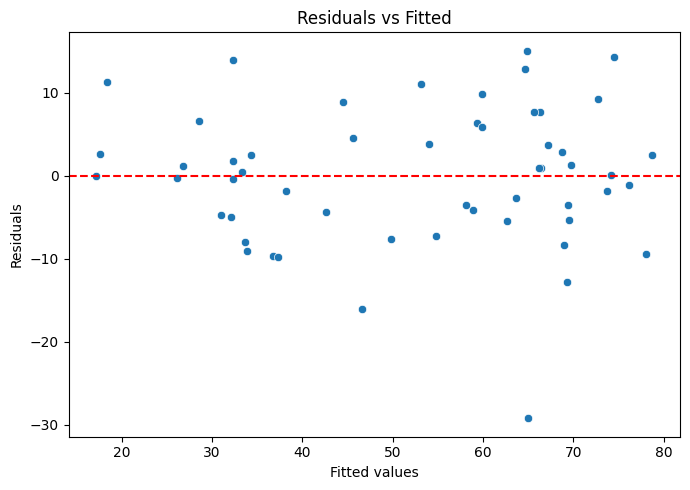

In [42]:
fitted_vals = vif_clean_model.fittedvalues
residuals = vif_clean_model.resid

plt.figure(figsize=(7,5))
sns.scatterplot(x=fitted_vals, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.tight_layout()
plt.show()

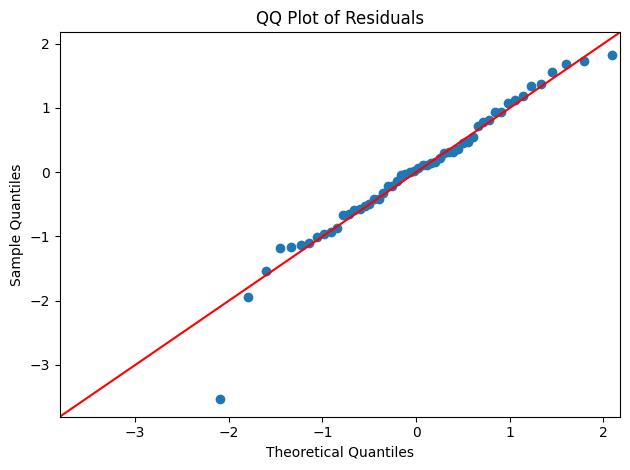

In [43]:
sm.qqplot(vif_clean_model.resid, line='45', fit=True)
plt.title("QQ Plot of Residuals")
plt.tight_layout()
plt.show()

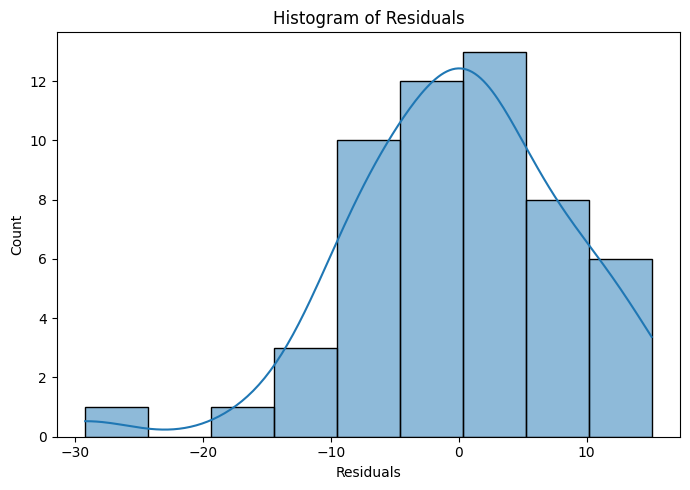

In [44]:
plt.figure(figsize=(7,5))
sns.histplot(vif_clean_model.resid, kde=True)
plt.xlabel("Residuals")
plt.title("Histogram of Residuals")
plt.tight_layout()
plt.show()

/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/statsmodels/stats/outliers_influence.py:847: RuntimeWarning: invalid value encountered in sqrt
  return self.resid / sigma / np.sqrt(1 - hii)


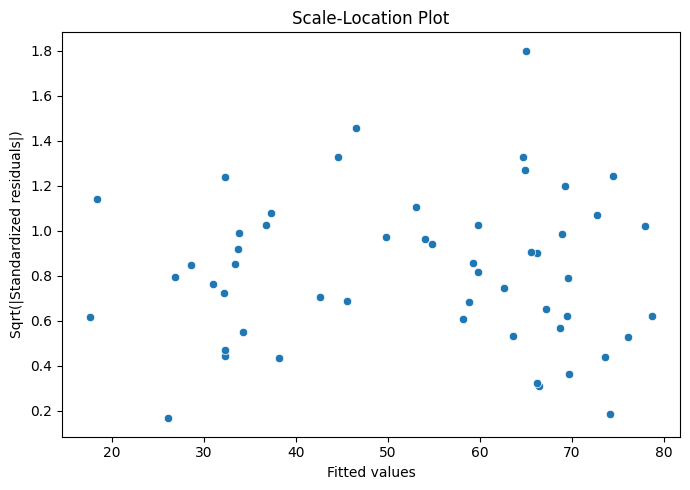

In [45]:
influence = vif_clean_model.get_influence()
std_resid = influence.resid_studentized_internal
sqrt_abs_std_resid = np.sqrt(np.abs(std_resid))

plt.figure(figsize=(7,5))
sns.scatterplot(x=fitted_vals, y=sqrt_abs_std_resid)
plt.xlabel("Fitted values")
plt.ylabel("Sqrt(|Standardized residuals|)")
plt.title("Scale-Location Plot")
plt.tight_layout()
plt.show()

In [46]:
bp_test = het_breuschpagan(vif_clean_model.resid, vif_clean_model.model.exog)

bp_results = pd.DataFrame({
    'Statistic': ['LM Statistic', 'LM p-value', 'F Statistic', 'F p-value'],
    'Value': bp_test
})

bp_results

,Statistic,Value
0,LM Statistic,12.499310
1,LM p-value,0.820418
2,F Statistic,0.585634
3,F p-value,0.886025


In [47]:
dw_stat = durbin_watson(vif_clean_model.resid)
print("Durbin-Watson statistic:", round(dw_stat, 4))

Durbin-Watson statistic: 1.9006


In [48]:
residual_df = pd.DataFrame({
    'index': df_variance_clean.index,
    'fitted': vif_clean_model.fittedvalues,
    'residual': vif_clean_model.resid
})

residual_df.head()

,index,fitted,residual
0,0,32.156854,-4.887624
1,1,59.854542,9.845458
2,2,66.261361,7.738639
3,3,58.842984,-4.142984
4,4,32.278202,13.921798


In [49]:
# Get influence measures from the fitted model
influence = OLSInfluence(vif_clean_model)

diagnostics_df = pd.DataFrame({
    'index': df_variance_clean.index,
    'studentized_residual': influence.resid_studentized_external,
    'cooks_distance': influence.cooks_distance[0]
})

/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/statsmodels/stats/outliers_influence.py:847: RuntimeWarning: invalid value encountered in sqrt
  return self.resid / sigma / np.sqrt(1 - hii)


In [50]:
n = len(df_variance_clean)
studentized_cutoff = 2
cooks_cutoff = 4 / n

In [51]:
# Flag points
diagnostics_df['outlier_by_studentized'] = diagnostics_df['studentized_residual'].abs() > studentized_cutoff
diagnostics_df['influential_by_cooks'] = diagnostics_df['cooks_distance'] > cooks_cutoff

In [52]:
# Final points flagged by either method
final_flagged_points = diagnostics_df[
    (diagnostics_df['outlier_by_studentized']) | (diagnostics_df['influential_by_cooks'])
].copy()

In [53]:
# Sort so the most suspicious points come first
final_flagged_points = final_flagged_points.sort_values(
    by=['outlier_by_studentized', 'cooks_distance'],
    ascending=False
)

In [54]:
print("Studentized residual cutoff:", studentized_cutoff)
print("Cook's distance cutoff:", round(cooks_cutoff, 4))

print("\nFinal flagged points:")
print(final_flagged_points)

Studentized residual cutoff: 2
Cook's distance cutoff: 0.0741

Final flagged points:
    index  studentized_residual  cooks_distance  outlier_by_studentized  \
23     23             -2.237063        0.201126                    True   
48     48             -3.815886        0.162596                    True   
38     38              0.721359        6.737458                   False   
17     17              0.628534        0.569902                   False   
53     53              1.818559        0.504256                   False   
15     15              0.929545        0.234951                   False   
28     28              1.815292        0.157300                   False   
32     32             -0.220566        0.122964                   False   

    influential_by_cooks  
23                  True  
48                  True  
38                  True  
17                  True  
53                  True  
15                  True  
28                  True  
32                  Tru

In [55]:
print(final_flagged_points['index'].tolist())

[23, 48, 38, 17, 53, 15, 28, 32]


### Fitting after removing influential points

In [56]:
flagged_points = [23, 48, 38, 17, 53, 15, 28, 32]

df_no_influential = df_variance_clean.drop(index=flagged_points).copy()

In [57]:
print("Original shape:", df_variance_clean.shape)
print("New shape after removing flagged points:", df_no_influential.shape)

Original shape: (54, 191)
New shape after removing flagged points: (46, 191)


In [58]:
X_new = df_no_influential[final_predictors].copy()
y_new = df_no_influential['ELA_Proficiency'].copy()

X_new = sm.add_constant(X_new)
model_no_influential = sm.OLS(y_new, X_new).fit()

print(model_no_influential.summary())

                            OLS Regression Results                            
Dep. Variable:        ELA_Proficiency   R-squared:                       0.901
Model:                            OLS   Adj. R-squared:                  0.835
Method:                 Least Squares   F-statistic:                     13.69
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           3.16e-09
Time:                        20:48:06   Log-Likelihood:                -149.43
No. Observations:                  46   AIC:                             336.9
Df Residuals:                      27   BIC:                             371.6
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                                                                                        coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------

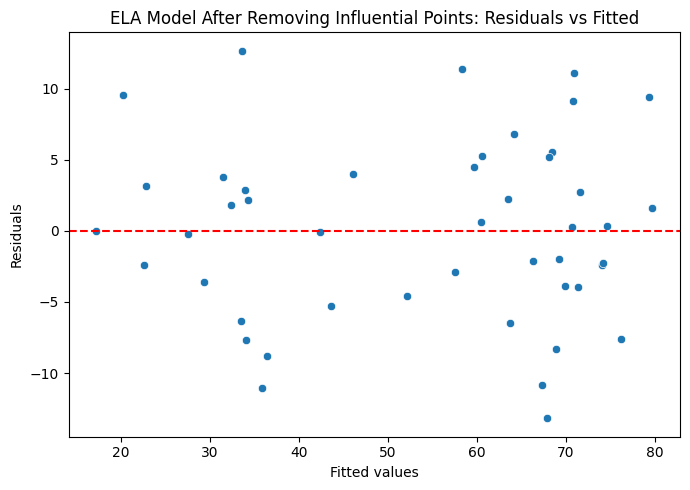

In [59]:
plt.figure(figsize=(7,5))
sns.scatterplot(x=model_no_influential.fittedvalues, y=model_no_influential.resid)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("ELA Model After Removing Influential Points: Residuals vs Fitted")
plt.tight_layout()
plt.show()

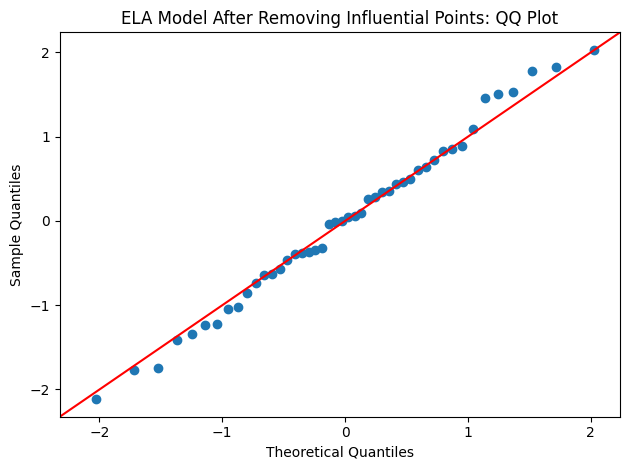

In [60]:
sm.qqplot(model_no_influential.resid, line='45', fit=True)
plt.title("ELA Model After Removing Influential Points: QQ Plot")
plt.tight_layout()
plt.show()

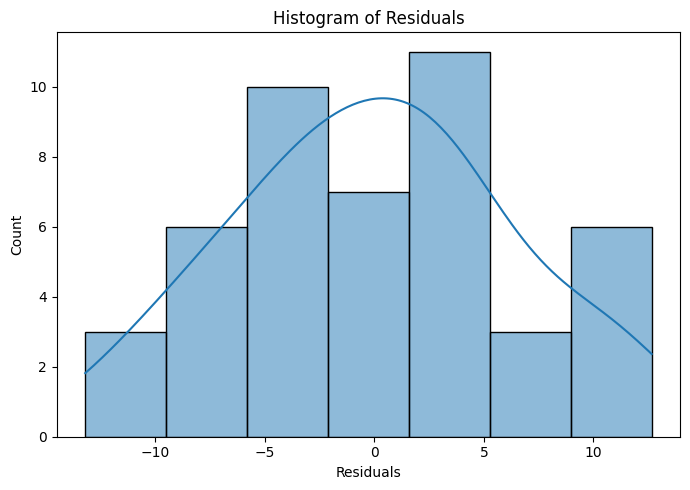

In [61]:
plt.figure(figsize=(7,5))
sns.histplot(model_no_influential.resid, kde=True)
plt.xlabel("Residuals")
plt.title("Histogram of Residuals")
plt.tight_layout()
plt.show()

In [62]:
bp_test_new = het_breuschpagan(model_no_influential.resid, model_no_influential.model.exog)

bp_results_new = pd.DataFrame({
    'Statistic': ['LM Statistic', 'LM p-value', 'F Statistic', 'F p-value'],
    'Value': bp_test_new
})

bp_results_new

,Statistic,Value
0,LM Statistic,11.403870
1,LM p-value,0.876439
2,F Statistic,0.494443
3,F p-value,0.938016


In [63]:
influence_new = OLSInfluence(model_no_influential)

diag_new = pd.DataFrame({
    'index': df_no_influential.index,
    'studentized_residual': influence_new.resid_studentized_external,
    'cooks_distance': influence_new.cooks_distance[0]
})

studentized_cutoff = 2
cooks_cutoff = 4 / len(df_no_influential)

diag_new['flag_outlier'] = diag_new['studentized_residual'].abs() > studentized_cutoff
diag_new['flag_influential'] = diag_new['cooks_distance'] > cooks_cutoff

final_flagged_new = diag_new[
    (diag_new['flag_outlier']) | (diag_new['flag_influential'])
].copy()

/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/statsmodels/stats/outliers_influence.py:847: RuntimeWarning: invalid value encountered in sqrt
  return self.resid / sigma / np.sqrt(1 - hii)


In [64]:
print("Studentized residual cutoff:", studentized_cutoff)
print("Cook's distance cutoff:", round(cooks_cutoff, 4))

print("\nRemaining flagged points after refitting:")
print(final_flagged_new)

Studentized residual cutoff: 2
Cook's distance cutoff: 0.087

Remaining flagged points after refitting:
    index  studentized_residual  cooks_distance  flag_outlier  \
3       3             -2.106825        0.103221          True   
10     10             -1.395346        0.109500         False   
14     14              0.982638        0.395694         False   
18     18              1.914934        2.519171         False   
31     31              1.843375        0.110483         False   
34     34              1.572716        0.087727         False   
35     35             -1.916704        0.154316         False   
37     37             -1.124132        0.197260         False   

    flag_influential  
3               True  
10              True  
14              True  
18              True  
31              True  
34              True  
35              True  
37              True  


/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/statsmodels/stats/outliers_influence.py:847: RuntimeWarning: invalid value encountered in sqrt
  return self.resid / sigma / np.sqrt(1 - hii)


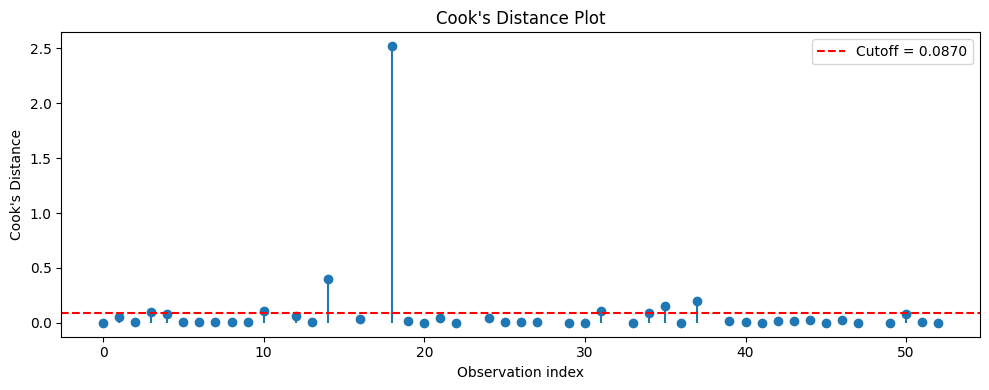

In [65]:
# influence measures from the refit model
influence = OLSInfluence(model_no_influential)
cooks_d = influence.cooks_distance[0]

# cutoff
n = len(df_no_influential)
cooks_cutoff = 4 / n

# Cook's distance plot
plt.figure(figsize=(10, 4))
plt.stem(df_no_influential.index, cooks_d, basefmt=" ")
plt.axhline(cooks_cutoff, color='red', linestyle='--', label=f"Cutoff = {cooks_cutoff:.4f}")
plt.xlabel("Observation index")
plt.ylabel("Cook's Distance")
plt.title("Cook's Distance Plot")
plt.legend()
plt.tight_layout()
plt.show()

### MODEL 2: RIDGE MODEL FOR ELA

In [66]:
vif_clean_nutrition_vars

['HEI 2015 Greens and Beans (0-5)',
 'HEI 2015 Whole Grains (0-10)',
 'Whole Fruit Servings in cup equivalents per 1000 kcal',
 'Seafood and Plant Protein Servings in ounce equivalents per 1000 kcal',
 'Galactose (g)',
 'Beta-Tocopherol (mg)',
 'Aspartame (mg)',
 '3-Methylhistidine (mg)',
 'TRANS 18:1 (trans-octadecenoic acid) (g)',
 'Synthetic Alpha-Tocopherol (all rac-alpha-tocopherol or dl-alpha-tocopherol) (mg)',
 'Daidzein (mg)',
 'Biochanin A (mg)',
 'Mannitol (g)',
 'Sorbitol (g)',
 'Tagatose (mg)',
 'Secoisolariciresinol (mcg)']

In [67]:
# choose outcome
target_outcome = 'ELA_Proficiency'   

# predictors: SES + filtered nutrition variables
ses_vars = ['student_low_income_percent', 'student_disabilities_percent']
ridge_predictors = ses_vars + vif_clean_nutrition_vars   

In [68]:
# build X and y
X = df_variance_clean[ridge_predictors].copy()
y = df_variance_clean[target_outcome].copy()

In [69]:
# scale X
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [70]:
# choose lambda (alpha) by cross-validation
alphas = np.logspace(-3, 3, 100)
ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_scaled, y)

best_alpha = ridge_cv.alpha_
print("Best lambda (alpha):", best_alpha)

/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = 

Best lambda (alpha): 13.219411484660288


In [71]:
# fit final ridge model
ridge_model = Ridge(alpha=best_alpha)
ridge_model.fit(X_scaled, y)

# coefficient table
ridge_coef_table = pd.DataFrame({
    'Predictor': ridge_predictors,
    'Ridge_Coefficient': ridge_model.coef_
}).sort_values('Ridge_Coefficient', key=np.abs, ascending=False)

print("\nTop coefficients:")
print(ridge_coef_table.head(20))


Top coefficients:
                                            Predictor  Ridge_Coefficient
0                          student_low_income_percent          -9.935254
15                                       Sorbitol (g)          -4.199096
9                              3-Methylhistidine (mg)          -2.967997
2                     HEI 2015 Greens and Beans (0-5)          -2.673970
5   Seafood and Plant Protein Servings in ounce eq...           2.132748
8                                      Aspartame (mg)          -2.104163
1                        student_disabilities_percent          -2.082186
6                                       Galactose (g)          -1.831090
3                        HEI 2015 Whole Grains (0-10)          -1.665120
10           TRANS 18:1 (trans-octadecenoic acid) (g)           1.405530
14                                       Mannitol (g)          -1.257020
12                                      Daidzein (mg)           1.131032
11  Synthetic Alpha-Tocopherol (

In [72]:
# cross-validated performance
cv_rmse = -cross_val_score(ridge_model, X_scaled, y, cv=5, scoring='neg_root_mean_squared_error')
cv_mae = -cross_val_score(ridge_model, X_scaled, y, cv=5, scoring='neg_mean_absolute_error')
cv_r2 = cross_val_score(ridge_model, X_scaled, y, cv=5, scoring='r2')

print("\nCV RMSE mean:", round(cv_rmse.mean(), 4))
print("CV MAE mean:", round(cv_mae.mean(), 4))
print("CV R^2 mean:", round(cv_r2.mean(), 4))


CV RMSE mean: 12.0845
CV MAE mean: 10.2172
CV R^2 mean: 0.6138


/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = 

In [73]:
zero_pct = (X == 0).mean().sort_values(ascending=False)
zero_pct.head(20)

Aspartame (mg)                                                                       0.981481
Synthetic Alpha-Tocopherol (all rac-alpha-tocopherol or dl-alpha-tocopherol) (mg)    0.925926
Whole Fruit Servings in cup equivalents per 1000 kcal                                0.055556
HEI 2015 Greens and Beans (0-5)                                                      0.037037
Seafood and Plant Protein Servings in ounce equivalents per 1000 kcal                0.037037
Biochanin A (mg)                                                                     0.018519
student_low_income_percent                                                           0.000000
Tagatose (mg)                                                                        0.000000
Sorbitol (g)                                                                         0.000000
Mannitol (g)                                                                         0.000000
Daidzein (mg)                                               

In [74]:
target_outcome = 'ELA_Proficiency'

ses_vars = ['student_low_income_percent', 'student_disabilities_percent']
ridge_predictors = ses_vars + vif_clean_nutrition_vars

X = df_variance_clean[ridge_predictors].copy()
y = df_variance_clean[target_outcome].copy()

# remove sparse variables (>80% zeros), except SES
zero_pct = (X == 0).mean()
sparse_drop = [col for col in X.columns if col not in ses_vars and zero_pct[col] > 0.80]

# manually remove highly skewed / unstable niche variables
manual_drop = [
    'Daidzein (mg)',
    'Tagatose (mg)',
    'Secoisolariciresinol (mcg)',
    'Biochanin A (mg)'
]

In [75]:
manual_drop = [col for col in manual_drop if col in X.columns]

drop_cols = list(set(sparse_drop + manual_drop))
X = X.drop(columns=drop_cols)

print("Dropped columns:")
print(drop_cols)

# log-transform nonnegative non-SES predictors
X_clean = X.copy()
for col in X_clean.columns:
    if col not in ses_vars and (X_clean[col] >= 0).all():
        X_clean[col] = np.log1p(X_clean[col])

# scale predictors
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)

Dropped columns:
['Aspartame (mg)', 'Secoisolariciresinol (mcg)', 'Daidzein (mg)', 'Tagatose (mg)', 'Synthetic Alpha-Tocopherol (all rac-alpha-tocopherol or dl-alpha-tocopherol) (mg)', 'Biochanin A (mg)']


In [76]:
# choose best lambda using CV
alphas = np.logspace(-3, 3, 100)
ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_scaled, y)

best_alpha = ridge_cv.alpha_
print("Best lambda (alpha):", best_alpha)

/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = 

Best lambda (alpha): 11.497569953977356


/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = 

In [77]:
# fit final ridge model
ridge_model_clean = Ridge(alpha=best_alpha)
ridge_model_clean.fit(X_scaled, y)

# coefficient table
ridge_coef_table_clean = pd.DataFrame({
    'Predictor': X_clean.columns,
    'Ridge_Coefficient': ridge_model_clean.coef_
}).sort_values('Ridge_Coefficient', key=np.abs, ascending=False)

print("\nTop coefficients:")
print(ridge_coef_table_clean.head(20))


Top coefficients:
                                            Predictor  Ridge_Coefficient
0                          student_low_income_percent         -10.596759
11                                       Sorbitol (g)          -3.968113
8                              3-Methylhistidine (mg)          -3.085033
2                     HEI 2015 Greens and Beans (0-5)          -2.910464
6                                       Galactose (g)          -2.746120
1                        student_disabilities_percent          -2.029209
3                        HEI 2015 Whole Grains (0-10)          -2.022839
5   Seafood and Plant Protein Servings in ounce eq...           1.897227
9            TRANS 18:1 (trans-octadecenoic acid) (g)           1.685244
7                                Beta-Tocopherol (mg)           0.960429
4   Whole Fruit Servings in cup equivalents per 10...          -0.581936
10                                       Mannitol (g)          -0.574629


In [78]:
# cross-validated performance
cv_rmse = -cross_val_score(ridge_model_clean, X_scaled, y, cv=5, scoring='neg_root_mean_squared_error')
cv_mae = -cross_val_score(ridge_model_clean, X_scaled, y, cv=5, scoring='neg_mean_absolute_error')
cv_r2 = cross_val_score(ridge_model_clean, X_scaled, y, cv=5, scoring='r2')

print("\nCV RMSE mean:", round(cv_rmse.mean(), 4))
print("CV MAE mean:", round(cv_mae.mean(), 4))
print("CV R^2 mean:", round(cv_r2.mean(), 4))


CV RMSE mean: 11.2965
CV MAE mean: 9.3775
CV R^2 mean: 0.6649


/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = 

### MODEL 3: Lasso on all predictors

In [79]:
df_variance_clean.columns

Index(['student_disabilities_percent', 'student_low_income_percent',
       'HEI 2015 Total Score', 'HEI 2015 Total Fruits (0-5)',
       'HEI 2015 Whole Fruits (0-5)', 'HEI 2015 Total Vegetables (0-5)',
       'HEI 2015 Greens and Beans (0-5)', 'HEI 2015 Whole Grains (0-10)',
       'HEI 2015 Dairy (0-10)', 'HEI 2015 Total Protein Foods (0-5)',
       ...
       'Total Lignans (mcg)', 'Secoisolariciresinol (mcg)',
       'Matairesinol (mcg)', 'Lariciresinol (mcg)', 'Pinoresinol (mcg)',
       'PUFA 18:2 n-6 (linoleic acid [LA]) (g)', 'Omega-6 Fatty Acids (g)',
       'ELA_Proficiency', 'Math_Proficiency', 'Science_Proficiency'],
      dtype='object', length=191)

In [80]:
df = df_variance_clean.copy()

target = 'ELA_Proficiency'
outcome_cols = ['ELA_Proficiency', 'Math_Proficiency', 'Science_Proficiency']

In [81]:
df = df_variance_clean.copy() 

target = 'ELA_Proficiency'
outcome_cols = ['ELA_Proficiency', 'Math_Proficiency', 'Science_Proficiency']

predictors = [col for col in df.columns if col not in outcome_cols]

print("Number of predictors:", len(predictors))

Number of predictors: 188


In [82]:
X = df[predictors].copy()
y = df[target].copy()

print(X.shape)
print(y.shape)

(54, 188)
(54,)


In [83]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [84]:
lasso_cv = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso_cv.fit(X_scaled, y)

best_alpha = lasso_cv.alpha_
print("Best lambda (alpha):", best_alpha)

Best lambda (alpha): 1.7060737810178273


In [85]:
lasso_model = Lasso(alpha=best_alpha, max_iter=10000)
lasso_model.fit(X_scaled, y)

Lasso(alpha=np.float64(1.7060737810178273), max_iter=10000)

In [86]:
lasso_coef_table = pd.DataFrame({
    'Predictor': X.columns,
    'Lasso_Coefficient': lasso_model.coef_
}).sort_values('Lasso_Coefficient', key=np.abs, ascending=False)

lasso_coef_table.head(30)

,Predictor,Lasso_Coefficient
1,student_low_income_percent,-12.261030
29,Total Fruit Servings in cup equivalents,-2.201706
142,Beta-Cryptoxanthin (provitamin A carotenoid) (...,-1.956298
99,MUFA 16:1 (palmitoleic acid) (g),-1.704929
12,HEI 2015 Refined Grains (0-10),-0.961111
0,student_disabilities_percent,-0.713603
65,Beta-Carotene Equivalents (derived from provit...,-0.690319
28,% Calories from SFA.x,-0.240138
23,Seafood and Plant Protein Servings in ounce eq...,0.202107
54,Galactose (g),-0.098801


In [87]:
lasso_selected = lasso_coef_table[lasso_coef_table['Lasso_Coefficient'] != 0].copy()
lasso_selected

,Predictor,Lasso_Coefficient
1,student_low_income_percent,-12.261030
29,Total Fruit Servings in cup equivalents,-2.201706
142,Beta-Cryptoxanthin (provitamin A carotenoid) (...,-1.956298
99,MUFA 16:1 (palmitoleic acid) (g),-1.704929
12,HEI 2015 Refined Grains (0-10),-0.961111
0,student_disabilities_percent,-0.713603
65,Beta-Carotene Equivalents (derived from provit...,-0.690319
28,% Calories from SFA.x,-0.240138
23,Seafood and Plant Protein Servings in ounce eq...,0.202107
54,Galactose (g),-0.098801


In [88]:
selected_predictors = lasso_selected['Predictor'].tolist()

print("Selected predictors:")
print(selected_predictors)
print("Number selected:", len(selected_predictors))

Selected predictors:
['student_low_income_percent', 'Total Fruit Servings in cup equivalents', 'Beta-Cryptoxanthin (provitamin A carotenoid) (mcg)', 'MUFA 16:1 (palmitoleic acid) (g)', 'HEI 2015 Refined Grains (0-10)', 'student_disabilities_percent', 'Beta-Carotene Equivalents (derived from provitamin A carotenoids) (mcg)', '% Calories from SFA.x', 'Seafood and Plant Protein Servings in ounce equivalents per 1000 kcal', 'Galactose (g)']
Number selected: 10


In [89]:
X_ols = df[selected_predictors].copy()
y_ols = df[target].copy()

X_ols = sm.add_constant(X_ols)
lasso_ols_model = sm.OLS(y_ols, X_ols).fit()

print(lasso_ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:        ELA_Proficiency   R-squared:                       0.818
Model:                            OLS   Adj. R-squared:                  0.776
Method:                 Least Squares   F-statistic:                     19.35
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           7.75e-13
Time:                        20:48:08   Log-Likelihood:                -191.53
No. Observations:                  54   AIC:                             405.1
Df Residuals:                      43   BIC:                             426.9
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                                                              coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------

In [90]:
cv_rmse = -cross_val_score(lasso_model, X_scaled, y, cv=5, scoring='neg_root_mean_squared_error')
cv_mae = -cross_val_score(lasso_model, X_scaled, y, cv=5, scoring='neg_mean_absolute_error')
cv_r2 = cross_val_score(lasso_model, X_scaled, y, cv=5, scoring='r2')

print("CV RMSE mean:", round(cv_rmse.mean(), 4))
print("CV MAE mean:", round(cv_mae.mean(), 4))
print("CV R^2 mean:", round(cv_r2.mean(), 4))

CV RMSE mean: 11.3288
CV MAE mean: 9.0311
CV R^2 mean: 0.6617


/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/ishita/Coder/Pro

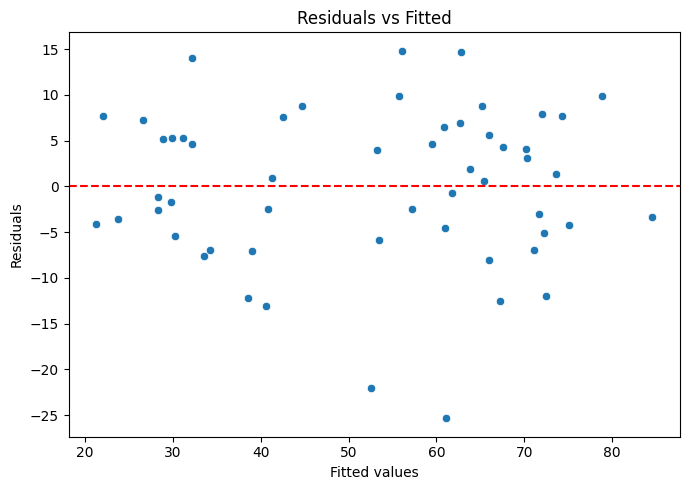

In [91]:
plt.figure(figsize=(7,5))
sns.scatterplot(x=lasso_ols_model.fittedvalues, y=lasso_ols_model.resid)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.tight_layout()
plt.show()

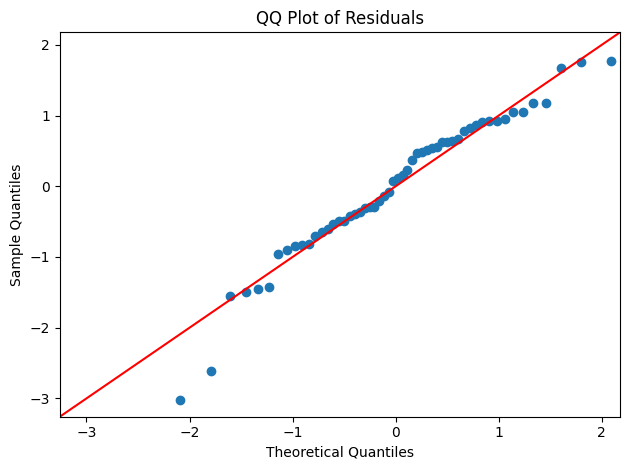

In [92]:
sm.qqplot(lasso_ols_model.resid, line='45', fit=True)
plt.title("QQ Plot of Residuals")
plt.tight_layout()
plt.show()

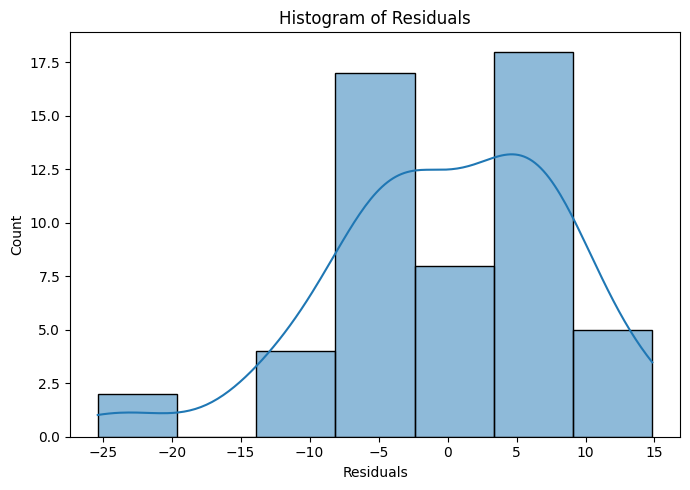

In [93]:
plt.figure(figsize=(7,5))
sns.histplot(lasso_ols_model.resid, kde=True)
plt.xlabel("Residuals")
plt.title("Histogram of Residuals")
plt.tight_layout()
plt.show()

In [94]:
bp_test = het_breuschpagan(lasso_ols_model.resid, lasso_ols_model.model.exog)

bp_results = pd.DataFrame({
    "Statistic": ["LM Statistic", "LM p-value", "F Statistic", "F p-value"],
    "Value": bp_test
})

bp_results

,Statistic,Value
0,LM Statistic,7.734534
1,LM p-value,0.654749
2,F Statistic,0.718862
3,F p-value,0.702179


In [95]:
influence = OLSInfluence(lasso_ols_model)

diagnostics_df = pd.DataFrame({
    "index": df.index,   # use the same dataframe used to fit lasso_ols_model
    "studentized_residual": influence.resid_studentized_external,
    "leverage": influence.hat_matrix_diag,
    "cooks_distance": influence.cooks_distance[0],
    "dffits": influence.dffits[0]
})

diagnostics_df.head()

,index,studentized_residual,leverage,cooks_distance,dffits
0,0,-0.859022,0.270549,0.025033,-0.523154
1,1,0.784886,0.118249,0.007578,0.287430
2,2,1.027313,0.176554,0.020544,0.475689
3,3,-0.323411,0.350154,0.005232,-0.237399
4,4,1.660662,0.165394,0.047732,0.739265


In [96]:
n = len(diagnostics_df)
p = lasso_ols_model.df_model + 1   # includes intercept

studentized_cutoff = 2
cooks_cutoff = 4 / n
leverage_cutoff = 2 * p / n
dffits_cutoff = 2 * np.sqrt(p / n)

print("Studentized residual cutoff:", round(studentized_cutoff, 4))
print("Cook's distance cutoff:", round(cooks_cutoff, 4))
print("Leverage cutoff:", round(leverage_cutoff, 4))
print("DFFITS cutoff:", round(dffits_cutoff, 4))

Studentized residual cutoff: 2
Cook's distance cutoff: 0.0741
Leverage cutoff: 0.4074
DFFITS cutoff: 0.9027


In [97]:
diagnostics_df["flag_studentized"] = diagnostics_df["studentized_residual"].abs() > studentized_cutoff
diagnostics_df["flag_cooks"] = diagnostics_df["cooks_distance"] > cooks_cutoff
diagnostics_df["flag_leverage"] = diagnostics_df["leverage"] > leverage_cutoff
diagnostics_df["flag_dffits"] = diagnostics_df["dffits"].abs() > dffits_cutoff

diagnostics_df["n_flags"] = diagnostics_df[
    ["flag_studentized", "flag_cooks", "flag_leverage", "flag_dffits"]
].sum(axis=1)

final_flagged_points = diagnostics_df[diagnostics_df["n_flags"] >= 1].copy()
final_flagged_points.sort_values(["n_flags", "cooks_distance"], ascending=[False, False])

,index,studentized_residual,leverage,cooks_distance,dffits,flag_studentized,flag_cooks,flag_leverage,flag_dffits,n_flags
53,53,1.719756,0.690096,0.572650,2.566304,False,True,True,True,3
48,48,-3.684072,0.308793,0.426513,-2.462396,True,True,False,True,3
23,23,-3.051045,0.299988,0.303933,-1.997319,True,True,False,True,3
14,14,0.657371,0.573277,0.053483,0.761938,False,False,True,False,1


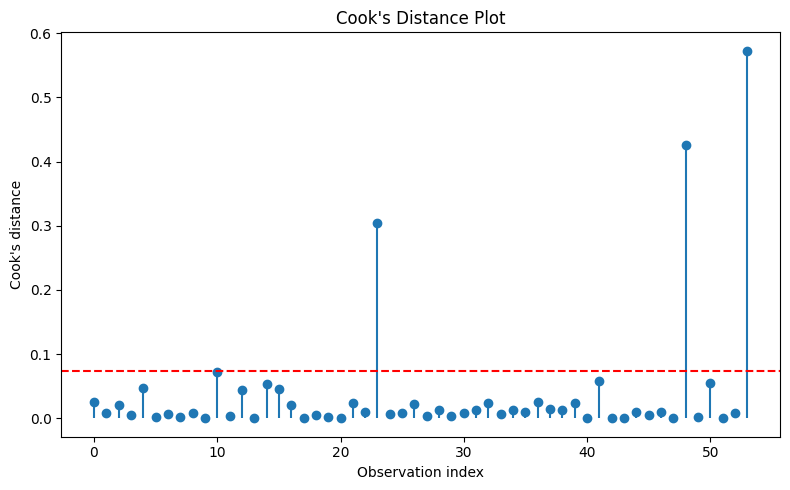

In [98]:
plt.figure(figsize=(8,5))
plt.stem(diagnostics_df["index"], diagnostics_df["cooks_distance"], basefmt=" ")
plt.axhline(cooks_cutoff, color="red", linestyle="--")
plt.xlabel("Observation index")
plt.ylabel("Cook's distance")
plt.title("Cook's Distance Plot")
plt.tight_layout()
plt.show()

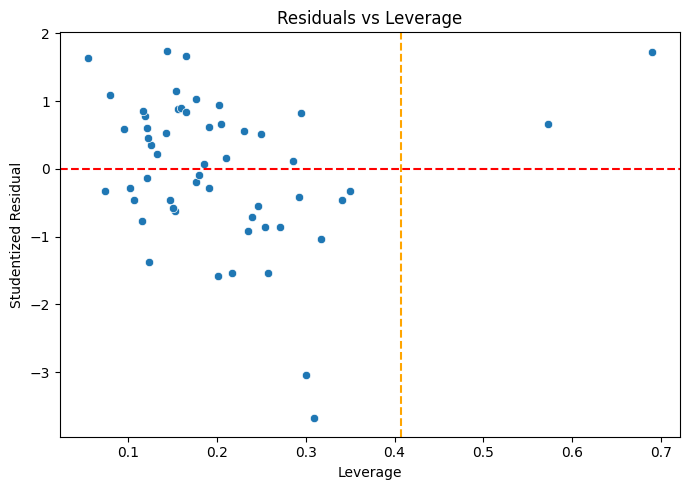

In [99]:
plt.figure(figsize=(7,5))
sns.scatterplot(x=diagnostics_df["leverage"], y=diagnostics_df["studentized_residual"])
plt.axhline(0, color="red", linestyle="--")
plt.axvline(leverage_cutoff, color="orange", linestyle="--")
plt.xlabel("Leverage")
plt.ylabel("Studentized Residual")
plt.title("Residuals vs Leverage")
plt.tight_layout()
plt.show()

In [100]:
X_vif = X_ols.drop(columns="const").copy()

vif_df = pd.DataFrame({
    "Predictor": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values("VIF", ascending=False)

vif_df

,Predictor,VIF
7,% Calories from SFA.x,24.127464
5,student_disabilities_percent,23.542275
1,Total Fruit Servings in cup equivalents,10.565615
4,HEI 2015 Refined Grains (0-10),10.451025
3,MUFA 16:1 (palmitoleic acid) (g),8.899750
2,Beta-Cryptoxanthin (provitamin A carotenoid) (...,8.302195
6,Beta-Carotene Equivalents (derived from provit...,8.142942
0,student_low_income_percent,4.279712
9,Galactose (g),3.606223
8,Seafood and Plant Protein Servings in ounce eq...,2.789900


### Fitting after handling influential points

In [101]:
lasso_selected_predictors = [
    'student_low_income_percent',
    'Total Fruit Servings in cup equivalents',
    'Beta-Cryptoxanthin (provitamin A carotenoid) (mcg)',
    'MUFA 16:1 (palmitoleic acid) (g)',
    'HEI 2015 Refined Grains (0-10)',
    'student_disabilities_percent',
    'Beta-Carotene Equivalents (derived from provitamin A carotenoids) (mcg)',
    '% Calories from SFA.x',
    'Seafood and Plant Protein Servings in ounce equivalents per 1000 kcal',
    'Galactose (g)'
]

In [102]:
influential_points = [23, 48, 53]

df_ela_clean = df.copy().drop(index=influential_points).copy()

print("Original shape:", df.shape)
print("New shape:", df_ela_clean.shape)

Original shape: (54, 191)
New shape: (51, 191)


In [103]:
X1 = df_ela_clean[lasso_selected_predictors].copy()
y1 = df_ela_clean['ELA_Proficiency'].copy()

X1 = sm.add_constant(X1)
ela_lasso_ols_clean1 = sm.OLS(y1, X1).fit()

print(ela_lasso_ols_clean1.summary())

                            OLS Regression Results                            
Dep. Variable:        ELA_Proficiency   R-squared:                       0.896
Model:                            OLS   Adj. R-squared:                  0.870
Method:                 Least Squares   F-statistic:                     34.35
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           1.62e-16
Time:                        20:48:08   Log-Likelihood:                -167.22
No. Observations:                  51   AIC:                             356.4
Df Residuals:                      40   BIC:                             377.7
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                                                              coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------

In [104]:
X1_vif = X1.drop(columns='const').copy()

vif1 = pd.DataFrame({
    'Predictor': X1_vif.columns,
    'VIF': [variance_inflation_factor(X1_vif.values, i) for i in range(X1_vif.shape[1])]
}).sort_values('VIF', ascending=False)

vif1

,Predictor,VIF
5,student_disabilities_percent,31.902958
7,% Calories from SFA.x,27.458083
4,HEI 2015 Refined Grains (0-10),10.761198
1,Total Fruit Servings in cup equivalents,9.905133
3,MUFA 16:1 (palmitoleic acid) (g),8.882329
6,Beta-Carotene Equivalents (derived from provit...,8.544173
2,Beta-Cryptoxanthin (provitamin A carotenoid) (...,8.053093
9,Galactose (g),5.469677
0,student_low_income_percent,4.735865
8,Seafood and Plant Protein Servings in ounce eq...,2.896689


In [105]:
predictors_step2 = [col for col in lasso_selected_predictors if col != '% Calories from SFA.x']
print(predictors_step2)

['student_low_income_percent', 'Total Fruit Servings in cup equivalents', 'Beta-Cryptoxanthin (provitamin A carotenoid) (mcg)', 'MUFA 16:1 (palmitoleic acid) (g)', 'HEI 2015 Refined Grains (0-10)', 'student_disabilities_percent', 'Beta-Carotene Equivalents (derived from provitamin A carotenoids) (mcg)', 'Seafood and Plant Protein Servings in ounce equivalents per 1000 kcal', 'Galactose (g)']


In [106]:
X2 = df_ela_clean[predictors_step2].copy()
y2 = df_ela_clean['ELA_Proficiency'].copy()

X2 = sm.add_constant(X2)
ela_lasso_ols_clean2 = sm.OLS(y2, X2).fit()

print(ela_lasso_ols_clean2.summary())

                            OLS Regression Results                            
Dep. Variable:        ELA_Proficiency   R-squared:                       0.894
Model:                            OLS   Adj. R-squared:                  0.870
Method:                 Least Squares   F-statistic:                     38.26
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           3.73e-17
Time:                        20:48:08   Log-Likelihood:                -167.73
No. Observations:                  51   AIC:                             355.5
Df Residuals:                      41   BIC:                             374.8
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                                                              coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------

In [107]:
X2_vif = X2.drop(columns='const').copy()

vif2 = pd.DataFrame({
    'Predictor': X2_vif.columns,
    'VIF': [variance_inflation_factor(X2_vif.values, i) for i in range(X2_vif.shape[1])]
}).sort_values('VIF', ascending=False)

vif2

,Predictor,VIF
5,student_disabilities_percent,12.084585
4,HEI 2015 Refined Grains (0-10),10.650565
1,Total Fruit Servings in cup equivalents,9.755270
6,Beta-Carotene Equivalents (derived from provit...,8.528144
3,MUFA 16:1 (palmitoleic acid) (g),8.321276
2,Beta-Cryptoxanthin (provitamin A carotenoid) (...,8.040993
8,Galactose (g),5.365227
0,student_low_income_percent,4.600249
7,Seafood and Plant Protein Servings in ounce eq...,2.885772


In [108]:
predictors_step3 = [col for col in predictors_step2 if col != 'student_disabilities_percent']
print(predictors_step3)

['student_low_income_percent', 'Total Fruit Servings in cup equivalents', 'Beta-Cryptoxanthin (provitamin A carotenoid) (mcg)', 'MUFA 16:1 (palmitoleic acid) (g)', 'HEI 2015 Refined Grains (0-10)', 'Beta-Carotene Equivalents (derived from provitamin A carotenoids) (mcg)', 'Seafood and Plant Protein Servings in ounce equivalents per 1000 kcal', 'Galactose (g)']


In [109]:
X3 = df_ela_clean[predictors_step3].copy()
y3 = df_ela_clean['ELA_Proficiency'].copy()

X3 = sm.add_constant(X3)
ela_lasso_ols_clean3 = sm.OLS(y3, X3).fit()

print(ela_lasso_ols_clean3.summary())

                            OLS Regression Results                            
Dep. Variable:        ELA_Proficiency   R-squared:                       0.886
Model:                            OLS   Adj. R-squared:                  0.864
Method:                 Least Squares   F-statistic:                     40.63
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           2.42e-17
Time:                        20:48:08   Log-Likelihood:                -169.58
No. Observations:                  51   AIC:                             357.2
Df Residuals:                      42   BIC:                             374.6
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                                                              coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------

In [110]:
X3_vif = X3.drop(columns='const').copy()

vif3 = pd.DataFrame({
    'Predictor': X3_vif.columns,
    'VIF': [variance_inflation_factor(X3_vif.values, i) for i in range(X3_vif.shape[1])]
}).sort_values('VIF', ascending=False)

vif3

,Predictor,VIF
1,Total Fruit Servings in cup equivalents,9.536599
2,Beta-Cryptoxanthin (provitamin A carotenoid) (...,7.970055
5,Beta-Carotene Equivalents (derived from provit...,7.850798
4,HEI 2015 Refined Grains (0-10),7.795145
3,MUFA 16:1 (palmitoleic acid) (g),6.811077
7,Galactose (g),5.228500
0,student_low_income_percent,3.865299
6,Seafood and Plant Protein Servings in ounce eq...,2.494298


In [111]:
predictors_step4 = [col for col in predictors_step3 if col != 'Total Fruit Servings in cup equivalents']
print(predictors_step4)

['student_low_income_percent', 'Beta-Cryptoxanthin (provitamin A carotenoid) (mcg)', 'MUFA 16:1 (palmitoleic acid) (g)', 'HEI 2015 Refined Grains (0-10)', 'Beta-Carotene Equivalents (derived from provitamin A carotenoids) (mcg)', 'Seafood and Plant Protein Servings in ounce equivalents per 1000 kcal', 'Galactose (g)']


In [112]:
X4 = df_ela_clean[predictors_step4].copy()
y4 = df_ela_clean['ELA_Proficiency'].copy()

X4 = sm.add_constant(X4)
ela_lasso_ols_clean4 = sm.OLS(y4, X4).fit()

print(ela_lasso_ols_clean4.summary())

                            OLS Regression Results                            
Dep. Variable:        ELA_Proficiency   R-squared:                       0.884
Model:                            OLS   Adj. R-squared:                  0.865
Method:                 Least Squares   F-statistic:                     46.66
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           4.78e-18
Time:                        20:48:08   Log-Likelihood:                -170.01
No. Observations:                  51   AIC:                             356.0
Df Residuals:                      43   BIC:                             371.5
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                                                              coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------

In [113]:
X4_vif = X4.drop(columns='const').copy()

vif4 = pd.DataFrame({
    'Predictor': X4_vif.columns,
    'VIF': [variance_inflation_factor(X4_vif.values, i) for i in range(X4_vif.shape[1])]
}).sort_values('VIF', ascending=False)

vif4

,Predictor,VIF
4,Beta-Carotene Equivalents (derived from provit...,7.842245
2,MUFA 16:1 (palmitoleic acid) (g),6.779534
1,Beta-Cryptoxanthin (provitamin A carotenoid) (...,6.207166
3,HEI 2015 Refined Grains (0-10),6.150410
6,Galactose (g),5.063795
0,student_low_income_percent,3.850239
5,Seafood and Plant Protein Servings in ounce eq...,2.308856


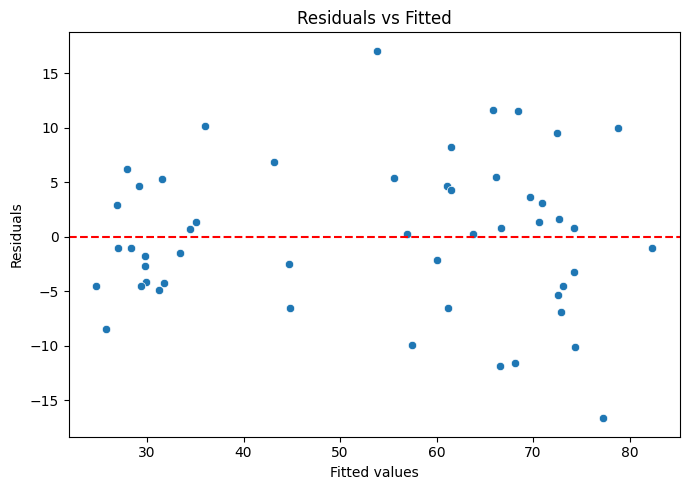

In [114]:
final_model = ela_lasso_ols_clean4  

plt.figure(figsize=(7,5))
sns.scatterplot(x=final_model.fittedvalues, y=final_model.resid)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.tight_layout()
plt.show()

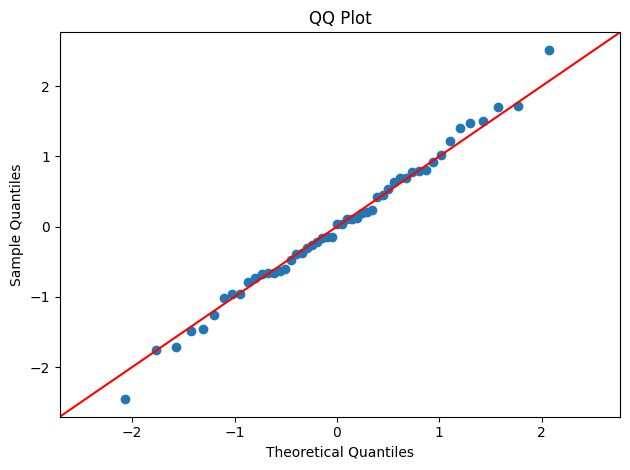

In [115]:
sm.qqplot(final_model.resid, line='45', fit=True)
plt.title("QQ Plot")
plt.tight_layout()
plt.show()

In [116]:
bp = het_breuschpagan(final_model.resid, final_model.model.exog)
print("Breusch-Pagan p-value:", bp[1])
print("Durbin-Watson:", durbin_watson(final_model.resid))

Breusch-Pagan p-value: 0.2857776483207991
Durbin-Watson: 2.5328355591526446


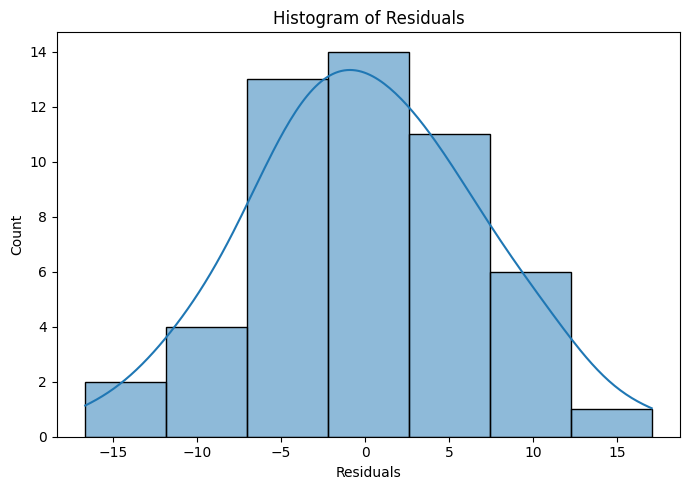

In [117]:
plt.figure(figsize=(7,5))
sns.histplot(final_model.resid, kde=True)
plt.xlabel("Residuals")
plt.title("Histogram of Residuals")
plt.tight_layout()
plt.show()

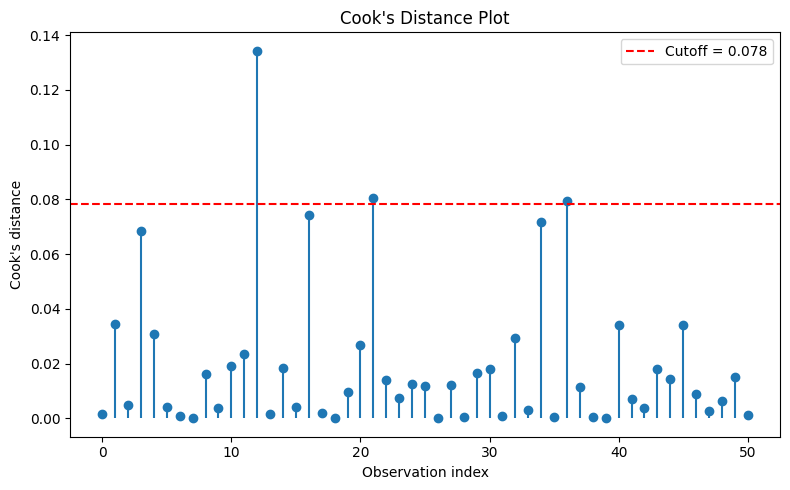

In [118]:
influence = OLSInfluence(final_model)

cooks_d = influence.cooks_distance[0]
n = len(cooks_d)
cooks_cutoff = 4 / n

plt.figure(figsize=(8,5))
plt.stem(range(n), cooks_d, basefmt=" ")
plt.axhline(cooks_cutoff, color="red", linestyle="--", label=f"Cutoff = {cooks_cutoff:.3f}")
plt.xlabel("Observation index")
plt.ylabel("Cook's distance")
plt.title("Cook's Distance Plot")
plt.legend()
plt.tight_layout()
plt.show()

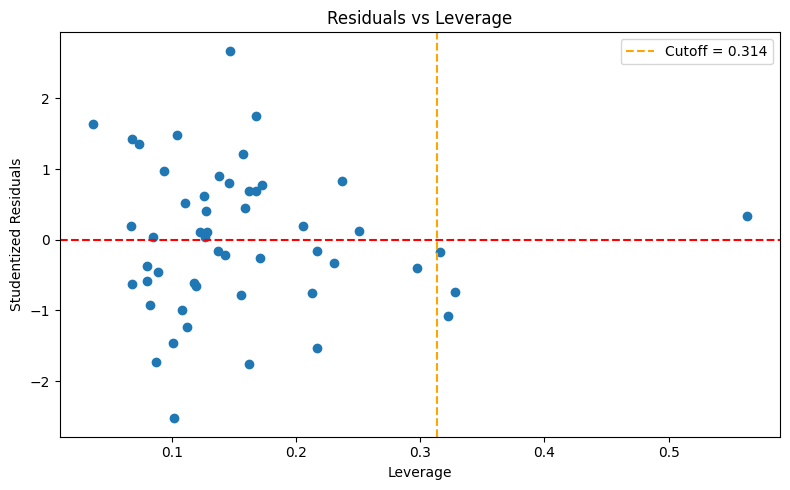

In [119]:
leverage = influence.hat_matrix_diag
studentized_resid = influence.resid_studentized_external

p = final_model.df_model + 1
leverage_cutoff = 2 * p / n

plt.figure(figsize=(8,5))
plt.scatter(leverage, studentized_resid)
plt.axhline(0, color="red", linestyle="--")
plt.axvline(leverage_cutoff, color="orange", linestyle="--", label=f"Cutoff = {leverage_cutoff:.3f}")
plt.xlabel("Leverage")
plt.ylabel("Studentized Residuals")
plt.title("Residuals vs Leverage")
plt.legend()
plt.tight_layout()
plt.show()